# 📊 **Adidas Quarterly Sales — Exploratory Data Analysis (EDA)**

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- The required Python libraries are imported for data manipulation, numerical analysis, and visualization.

# Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/HP/Downloads/adidas-quarterly-sales.csv")
df

,Time Period,Revenue
0,2000Q1,1517
1,2000Q2,1248
2,2000Q3,1677
3,2000Q4,1393
4,2001Q1,1558
...,...,...
83,2020Q4,5142
84,2021Q1,5268
85,2021Q2,5077
86,2021Q3,5752


- The dataset contains quarterly Adidas revenue data, with each row representing one quarter.

 # Check Dataset Size

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 88
Number of Columns: 2


- The dataset contains 88 rows and 2 columns, representing 88 quarterly observations.

# Display Column Names

In [5]:
print(df.columns)

Index(['Time Period', 'Revenue'], dtype='object')


- The dataset contains two main variables: Time Period and Revenue.

# Check Data Types

In [6]:
df.dtypes

Time Period    object
Revenue         int64
dtype: object

- Time Period is stored as text, while Revenue is stored as an integer.

# Check Missing Values

In [7]:
df.isnull().sum()

Time Period    0
Revenue        0
dtype: int64

- This checks whether any quarterly records contain missing values.

# Check Duplicate Records

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


- Duplicate records can affect analysis, so they are checked before further processing.

# Generate Statistical Summary

In [9]:
df.describe()

,Revenue
count,88.000000
mean,3302.034091
std,1477.855719
min,1078.000000
25%,1864.250000
50%,3162.000000
75%,4457.500000
max,6410.000000


- The statistical summary shows the average, minimum, maximum, and variation in quarterly revenue.

# 📈 **Data Visualization**

 # Quarterly Revenue Trend

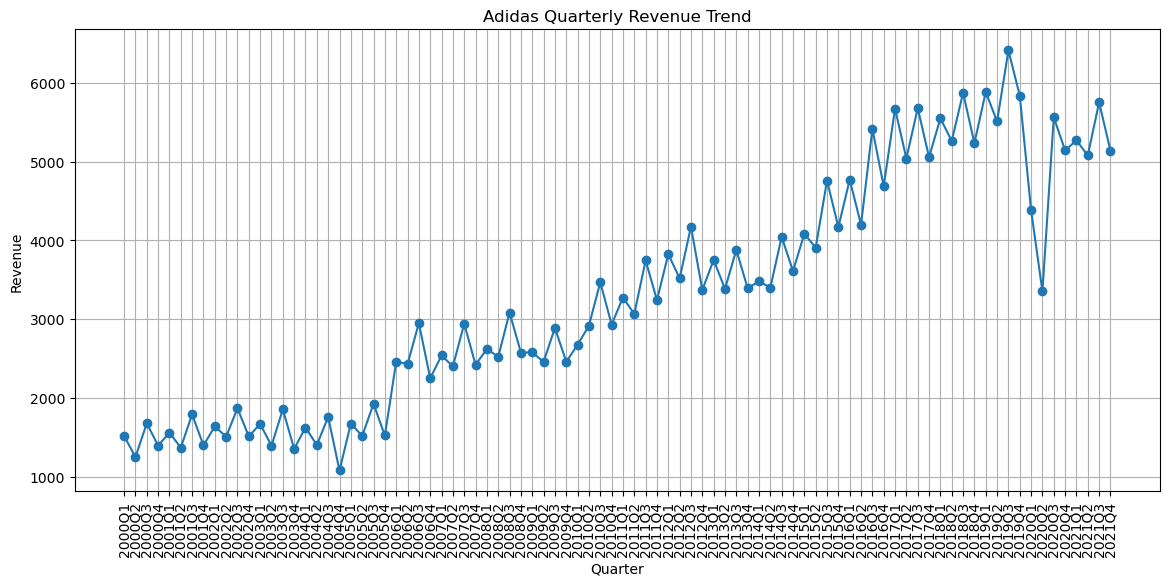

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df["Time Period"], df["Revenue"], marker="o")

plt.title("Adidas Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

- The line chart shows how Adidas revenue changes across quarters and helps identify periods of growth and decline.

# Revenue Distribution

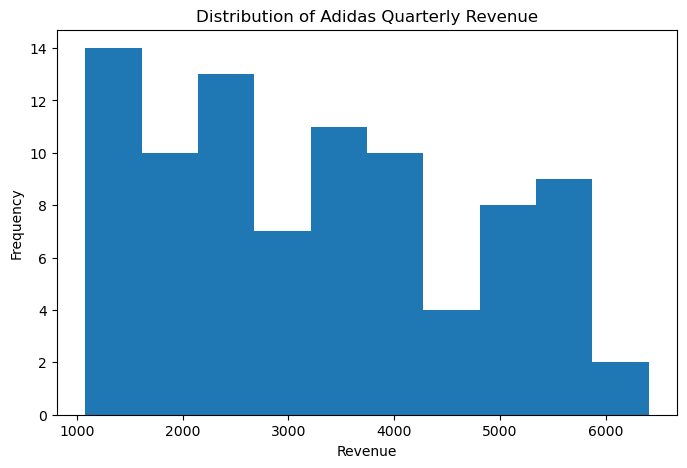

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["Revenue"], bins=10)

plt.title("Distribution of Adidas Quarterly Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

- The histogram shows how frequently different revenue levels occur throughout the dataset.

# Revenue Boxplot

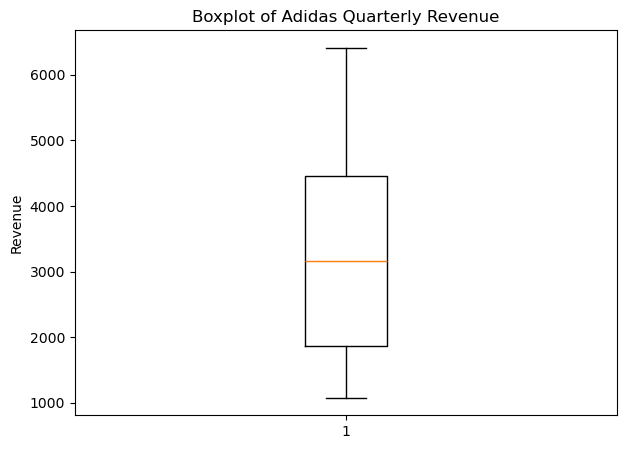

In [12]:
plt.figure(figsize=(7,5))

plt.boxplot(df["Revenue"])

plt.title("Boxplot of Adidas Quarterly Revenue")
plt.ylabel("Revenue")

plt.show()

- The boxplot helps identify the spread of revenue and possible unusually high or low quarterly values.

# **📅 Time-Based Analysis**

# Extract Year and Quarter

In [13]:
df["Year"] = df["Time Period"].str[:4].astype(int)
df["Quarter"] = df["Time Period"].str[-2:]

df.head()

,Time Period,Revenue,Year,Quarter
0,2000Q1,1517,2000,Q1
1,2000Q2,1248,2000,Q2
2,2000Q3,1677,2000,Q3
3,2000Q4,1393,2000,Q4
4,2001Q1,1558,2001,Q1


- The time-period column is separated into Year and Quarter to make yearly and seasonal analysis easier.


# Yearly Revenue

In [14]:
yearly_revenue = df.groupby("Year")["Revenue"].sum()

print(yearly_revenue)

Year
2000     5835
2001     6112
2002     6523
2003     6267
2004     5860
2005     6636
2006    10084
2007    10299
2008    10799
2009    10380
2010    11990
2011    13322
2012    14883
2013    14404
2014    14534
2015    16915
2016    19068
2017    21442
2018    21916
2019    23640
2020    18436
2021    21234
Name: Revenue, dtype: int64


- Yearly revenue allows us to understand the overall annual performance of Adidas.

# Plot Yearly Revenue

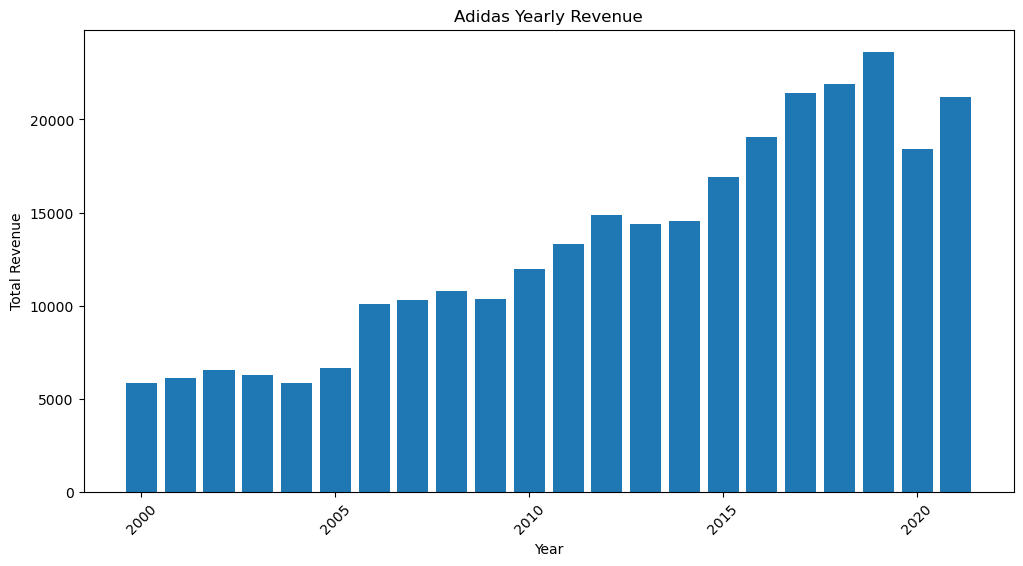

In [15]:
plt.figure(figsize=(12,6))

plt.bar(yearly_revenue.index, yearly_revenue.values)

plt.title("Adidas Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

- The bar chart makes it easier to compare Adidas revenue performance across different years.

# Average Revenue by Quarter

In [16]:
quarterly_avg = df.groupby("Quarter")["Revenue"].mean()

print(quarterly_avg)

Quarter
Q1    3294.500000
Q2    3039.181818
Q3    3703.772727
Q4    3170.681818
Name: Revenue, dtype: float64


- Average revenue by quarter helps identify possible seasonal patterns in Adidas sales.

# Quarterly Seasonal Pattern

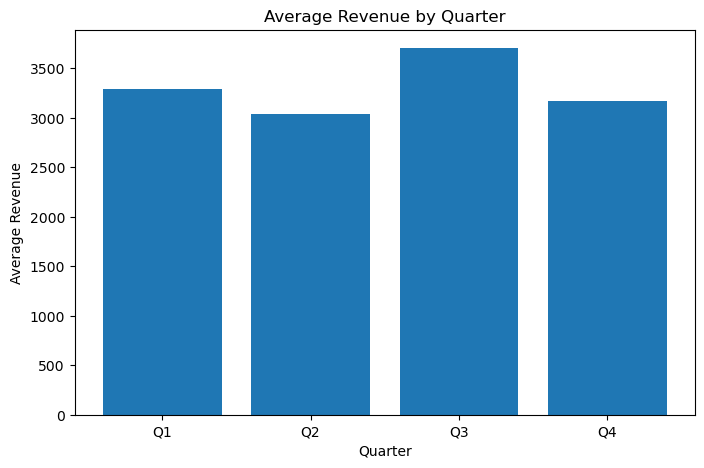

In [17]:
plt.figure(figsize=(8,5))

plt.bar(quarterly_avg.index, quarterly_avg.values)

plt.title("Average Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Revenue")

plt.show()

- This visualization highlights which quarter generally records higher or lower revenue.

# 🔍 **Revenue Analysis**

# Highest Revenue Quarter

In [18]:
highest = df.loc[df["Revenue"].idxmax()]

print("Highest Revenue Quarter:", highest["Time Period"])
print("Highest Revenue:", highest["Revenue"])

Highest Revenue Quarter: 2019Q3
Highest Revenue: 6410


- This identifies the quarter with the highest recorded revenue in the dataset.

# Lowest Revenue Quarter

In [19]:
lowest = df.loc[df["Revenue"].idxmin()]

print("Lowest Revenue Quarter:", lowest["Time Period"])
print("Lowest Revenue:", lowest["Revenue"])

Lowest Revenue Quarter: 2004Q4
Lowest Revenue: 1078


- This identifies the quarter with the lowest recorded revenue.

# Average Revenue

In [20]:
average_revenue = df["Revenue"].mean()

print("Average Quarterly Revenue:", round(average_revenue, 2))

Average Quarterly Revenue: 3302.03


- The average represents the typical quarterly revenue level across the entire dataset.

# Median Revenue

In [21]:
median_revenue = df["Revenue"].median()

print("Median Quarterly Revenue:", median_revenue)

Median Quarterly Revenue: 3162.0


- The median shows the middle revenue value and is useful for understanding the typical quarter without being strongly affected by extreme values.         

# Revenue Range

In [22]:
revenue_range = df["Revenue"].max() - df["Revenue"].min()

print("Revenue Range:", revenue_range)

Revenue Range: 5332


- The revenue range shows the difference between Adidas' highest and lowest quarterly revenue.

# 📊 **Growth Analysis**

# Quarter-over-Quarter Growth

In [23]:
df["QoQ_Growth_%"] = df["Revenue"].pct_change() * 100

df[["Time Period", "Revenue", "QoQ_Growth_%"]].head(10)

,Time Period,Revenue,QoQ_Growth_%
0,2000Q1,1517,NaN
1,2000Q2,1248,-17.732367
2,2000Q3,1677,34.375000
3,2000Q4,1393,-16.935003
4,2001Q1,1558,11.844939
5,2001Q2,1368,-12.195122
6,2001Q3,1790,30.847953
7,2001Q4,1396,-22.011173
8,2002Q1,1638,17.335244
9,2002Q2,1507,-7.997558


- Quarter-over-quarter growth shows how revenue changes compared with the immediately preceding quarter.

# Plot Revenue Growth

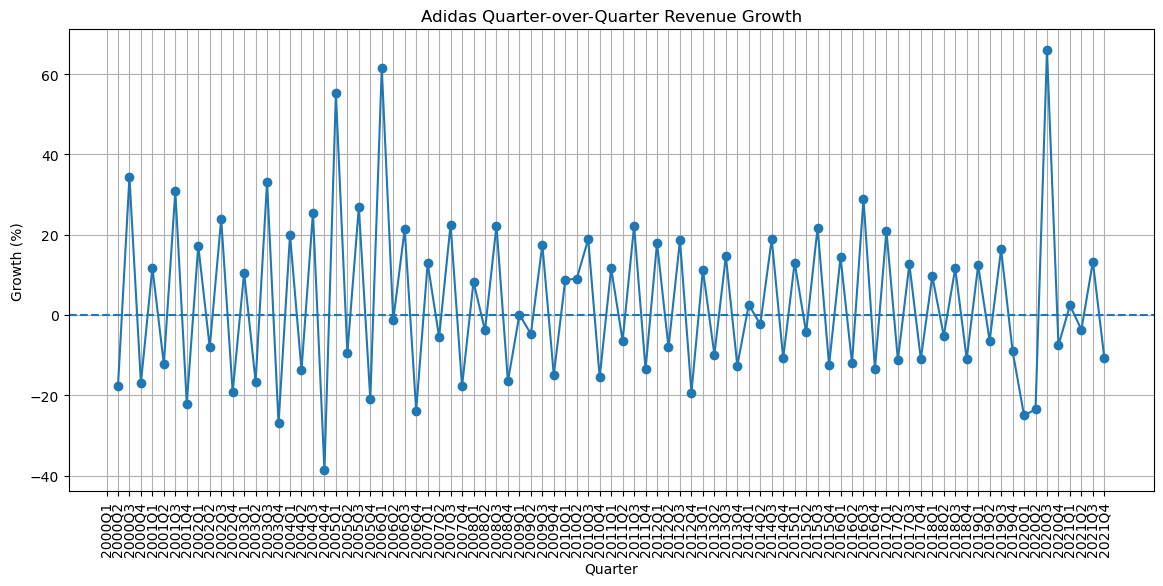

In [24]:
plt.figure(figsize=(14,6))

plt.plot(df["Time Period"], df["QoQ_Growth_%"], marker="o")

plt.axhline(0, linestyle="--")

plt.title("Adidas Quarter-over-Quarter Revenue Growth")
plt.xlabel("Quarter")
plt.ylabel("Growth (%)")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

- Positive values indicate quarterly revenue growth, while negative values indicate a decline compared with the previous quarter.

# Highest Growth Quarter

In [25]:
highest_growth = df.loc[df["QoQ_Growth_%"].idxmax()]

print("Highest Growth Quarter:", highest_growth["Time Period"])
print("Growth:", round(highest_growth["QoQ_Growth_%"], 2), "%")

Highest Growth Quarter: 2020Q3
Growth: 65.9 %


- This identifies the quarter with the strongest quarter-over-quarter revenue increase.

# Largest Revenue Decline

In [26]:
largest_decline = df.loc[df["QoQ_Growth_%"].idxmin()]

print("Largest Decline Quarter:", largest_decline["Time Period"])
print("Decline:", round(largest_decline["QoQ_Growth_%"], 2), "%")

Largest Decline Quarter: 2004Q4
Decline: -38.68 %


- This identifies the quarter with the largest decline compared with the previous quarter.

# 📌 **Additional Analysis**

# Top 10 Revenue Quarters

In [27]:
top_10 = df.nlargest(10, "Revenue")

print(top_10[["Time Period", "Revenue"]])

   Time Period  Revenue
78      2019Q3     6410
76      2019Q1     5883
74      2018Q3     5873
79      2019Q4     5838
86      2021Q3     5752
70      2017Q3     5677
68      2017Q1     5671
82      2020Q3     5561
72      2018Q1     5548
77      2019Q2     5509


- The table shows the ten quarters with the highest revenue values.

# Bottom 10 Revenue Quarters

In [28]:
bottom_10 = df.nsmallest(10, "Revenue")

print(bottom_10[["Time Period", "Revenue"]])

   Time Period  Revenue
19      2004Q4     1078
1       2000Q2     1248
15      2003Q4     1353
5       2001Q2     1368
13      2003Q2     1392
3       2000Q4     1393
7       2001Q4     1396
17      2004Q2     1401
9       2002Q2     1507
11      2002Q4     1510


- The table identifies the ten quarters with the lowest revenue values.

# Revenue Above Average

In [29]:
above_average = df[df["Revenue"] > df["Revenue"].mean()]

print(above_average[["Time Period", "Revenue"]])

   Time Period  Revenue
42      2010Q3     3468
46      2011Q3     3744
48      2012Q1     3824
49      2012Q2     3517
50      2012Q3     4173
51      2012Q4     3369
52      2013Q1     3751
53      2013Q2     3383
54      2013Q3     3879
55      2013Q4     3391
56      2014Q1     3480
57      2014Q2     3400
58      2014Q3     4044
59      2014Q4     3610
60      2015Q1     4083
61      2015Q2     3907
62      2015Q3     4758
63      2015Q4     4167
64      2016Q1     4769
65      2016Q2     4199
66      2016Q3     5413
67      2016Q4     4687
68      2017Q1     5671
69      2017Q2     5038
70      2017Q3     5677
71      2017Q4     5056
72      2018Q1     5548
73      2018Q2     5261
74      2018Q3     5873
75      2018Q4     5234
76      2019Q1     5883
77      2019Q2     5509
78      2019Q3     6410
79      2019Q4     5838
80      2020Q1     4381
81      2020Q2     3352
82      2020Q3     5561
83      2020Q4     5142
84      2021Q1     5268
85      2021Q2     5077
86      2021Q3  

- These are the quarters where Adidas generated revenue above the overall dataset average.

# Revenue Below Average

In [30]:
below_average = df[df["Revenue"] < df["Revenue"].mean()]

print(below_average[["Time Period", "Revenue"]])

   Time Period  Revenue
0       2000Q1     1517
1       2000Q2     1248
2       2000Q3     1677
3       2000Q4     1393
4       2001Q1     1558
5       2001Q2     1368
6       2001Q3     1790
7       2001Q4     1396
8       2002Q1     1638
9       2002Q2     1507
10      2002Q3     1868
11      2002Q4     1510
12      2003Q1     1669
13      2003Q2     1392
14      2003Q3     1853
15      2003Q4     1353
16      2004Q1     1623
17      2004Q2     1401
18      2004Q3     1758
19      2004Q4     1078
20      2005Q1     1674
21      2005Q2     1516
22      2005Q3     1924
23      2005Q4     1522
24      2006Q1     2459
25      2006Q2     2428
26      2006Q3     2949
27      2006Q4     2248
28      2007Q1     2538
29      2007Q2     2400
30      2007Q3     2941
31      2007Q4     2420
32      2008Q1     2621
33      2008Q2     2521
34      2008Q3     3083
35      2008Q4     2574
36      2009Q1     2577
37      2009Q2     2457
38      2009Q3     2888
39      2009Q4     2458
40      2010Q1  

- These quarters recorded revenue below the overall average.

# Yearly Growth

In [31]:
yearly_growth = yearly_revenue.pct_change() * 100

print(yearly_growth)

Year
2000          NaN
2001     4.747215
2002     6.724476
2003    -3.924575
2004    -6.494335
2005    13.242321
2006    51.959011
2007     2.132090
2008     4.854840
2009    -3.879989
2010    15.510597
2011    11.109258
2012    11.717460
2013    -3.218437
2014     0.902527
2015    16.382276
2016    12.728348
2017    12.450178
2018     2.210615
2019     7.866399
2020   -22.013536
2021    15.176828
Name: Revenue, dtype: float64


- Yearly growth shows how Adidas' total revenue changed from one year to the next.

# Plot Yearly Growth

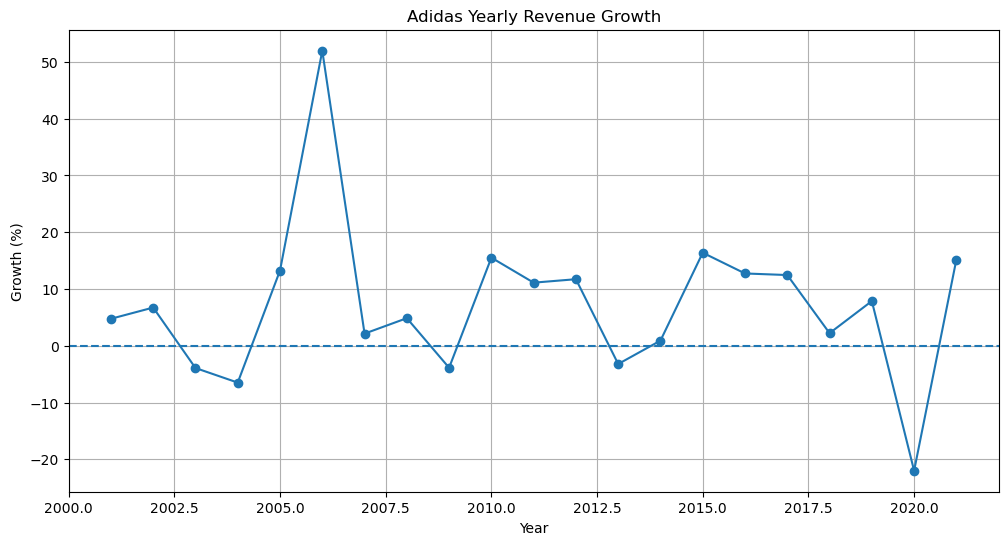

In [32]:
plt.figure(figsize=(12,6))

plt.plot(yearly_growth.index, yearly_growth.values, marker="o")

plt.axhline(0, linestyle="--")

plt.title("Adidas Yearly Revenue Growth")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.grid(True)

plt.show()

- The chart makes long-term increases and decreases in annual revenue easier to identify.

# 📊 **Correlation Analysis**

- Since the dataset mainly contains one numerical variable, correlation analysis is limited. We can still check the relationship between Year and Revenue.

# Correlation

In [33]:
correlation = df[["Year", "Revenue"]].corr()

print(correlation)

            Year  Revenue
Year     1.00000  0.94259
Revenue  0.94259  1.00000


- The correlation indicates whether revenue generally tends to increase or decrease as the years progress.

# Year vs Revenue

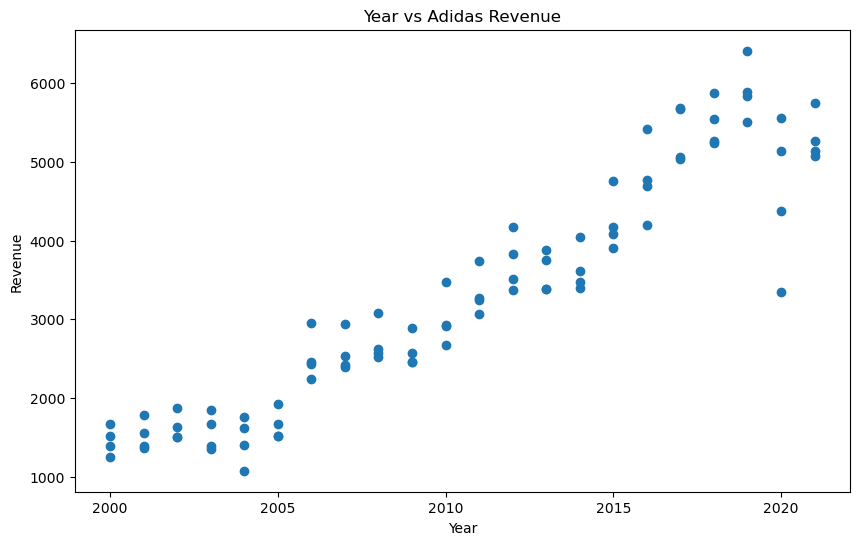

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(df["Year"], df["Revenue"])

plt.title("Year vs Adidas Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

- The scatter plot provides a visual view of the long-term relationship between year and quarterly revenue.

# 🏆 **Final EDA Summary**

In [35]:
print("========== ADIDAS EDA SUMMARY ==========")

print("Total Records:", len(df))
print("Average Quarterly Revenue:", round(df["Revenue"].mean(), 2))
print("Median Quarterly Revenue:", df["Revenue"].median())
print("Minimum Revenue:", df["Revenue"].min())
print("Maximum Revenue:", df["Revenue"].max())

print("Highest Revenue Quarter:",
      df.loc[df["Revenue"].idxmax(), "Time Period"])

print("Lowest Revenue Quarter:",
      df.loc[df["Revenue"].idxmin(), "Time Period"])

print("Highest Growth Quarter:",
      df.loc[df["QoQ_Growth_%"].idxmax(), "Time Period"])

print("Largest Decline Quarter:",
      df.loc[df["QoQ_Growth_%"].idxmin(), "Time Period"])

========== ADIDAS EDA SUMMARY ==========
Total Records: 88
Average Quarterly Revenue: 3302.03
Median Quarterly Revenue: 3162.0
Minimum Revenue: 1078
Maximum Revenue: 6410
Highest Revenue Quarter: 2019Q3
Lowest Revenue Quarter: 2004Q4
Highest Growth Quarter: 2020Q3
Largest Decline Quarter: 2004Q4


- This final section provides a compact summary of the major findings from the Adidas quarterly revenue dataset.

# 📝 **Overall Conclusion**

### ***The EDA of Adidas quarterly sales provides a clear view of revenue performance across multiple years and quarters. The analysis examines revenue distribution, yearly performance, quarterly seasonality, growth patterns, and major increases or declines. The visualizations make it easier to identify trends and unusual revenue movements. Overall, this analysis demonstrates how exploratory data analysis can be used to understand historical sales performance and identify important patterns in business data***.